# Redes Neuronales Recurrentes — Modelos de Forecasting

**Objetivo:** Entrenar modelos de redes neuronales recurrentes (GRU) para predecir el promedio 
del log-return de cierre futuro de 23 activos del S&P 500, a través de 16 combinaciones de ventanas 
temporales de entrada y salida.

**Métrica:** MAE (Mean Absolute Error)

In [32]:
import sys
import os

# Buscar el directorio raíz del proyecto localizando config.py
def find_project_root():
    path = os.getcwd()
    for _ in range(5):
        if os.path.exists(os.path.join(path, 'config.py')):
            return path
        path = os.path.dirname(path)
    return None

project_root = find_project_root()
if project_root:
    os.chdir(project_root)
    sys.path.insert(0, project_root)
    print(f"Directorio de trabajo: {os.getcwd()}")
else:
    print("ERROR: No se encontró el directorio raíz del proyecto")

Directorio de trabajo: /Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting


## 1. Imports y configuración

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# Infraestructura compartida del proyecto
from src.data_pipeline import load_data, get_train_test
from src.evaluation import compute_mae, save_results, count_parameters
from src.plotting import plot_training_curves
from config import INPUT_WINDOWS, OUTPUT_WINDOWS, FIGURES_DIR, MODELS_DIR, RANDOM_SEED

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

# Configuración de entrenamiento
BATCH_SIZE = 64
EPOCHS = 400
VAL_SPLIT = 0.1

print(f"TensorFlow version: {tf.__version__}")
print(f"Épocas: {EPOCHS} | Batch size: {BATCH_SIZE} | Validation split: {VAL_SPLIT}")
print(f"Ventanas entrada: {INPUT_WINDOWS}")
print(f"Ventanas salida: {OUTPUT_WINDOWS}")
print(f"Total combinaciones: {len(INPUT_WINDOWS) * len(OUTPUT_WINDOWS)}")

TensorFlow version: 2.21.0
Épocas: 400 | Batch size: 64 | Validation split: 0.1
Ventanas entrada: [5, 10, 30, 90]
Ventanas salida: [1, 5, 30, 90]
Total combinaciones: 16


## 2. Carga de datos

In [34]:
returns = load_data()
print(f"Shape: {returns.shape}")

[*********************100%***********************]  23 of 23 completed


Datos cargados: 16200 días, 23 activos
Rango: 1962-01-03 → 2026-05-15
Shape: (16200, 23)


## 3. Preparación de datos — Split de validación aleatorio

Se realiza el split de validación de forma aleatoria (`shuffle=True`) en lugar del split 
cronológico por defecto de Keras. Esto garantiza que los datos de validación provienen de 
todo el periodo temporal y tienen una distribución de volatilidad similar a los datos de 
entrenamiento, evitando sesgos por diferencias de régimen de mercado entre periodos.

El split se realiza manualmente antes del entrenamiento usando `train_test_split` de 
scikit-learn, y se pasa como `validation_data` a `model.fit()` en lugar de usar 
`validation_split`.

In [35]:
def prepare_train_val(X_train_full, y_train_full, val_size=0.1, seed=42):
    """
    Divide los datos de entrenamiento en train y validación con shuffle aleatorio.
    
    Parameters
    ----------
    X_train_full : np.ndarray
        Datos de entrada completos (antes de separar validación).
    y_train_full : np.ndarray
        Targets completos (antes de separar validación).
    val_size : float
        Proporción de datos para validación.
    seed : int
        Semilla para reproducibilidad.
    
    Returns
    -------
    X_tr, X_val, y_tr, y_val : np.ndarray
        Datos divididos aleatoriamente.
    """
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_full, y_train_full,
        test_size=val_size,
        shuffle=True,
        random_state=seed
    )
    return X_tr, X_val, y_tr, y_val

## 4. Arquitectura del modelo

### GRU con dos capas recurrentes apiladas

- **GRU (128 unidades, return_sequences=True):** Primera capa recurrente que procesa la 
  secuencia completa de entrada y pasa la secuencia de estados ocultos a la siguiente capa. 
  GRU (Gated Recurrent Unit) tiene menos parámetros por unidad que LSTM al no mantener un 
  cell state separado, lo que reduce el riesgo de sobreajuste.

- **Dropout (0.2):** Regularización entre capas recurrentes. Desactiva aleatoriamente el 20% 
  de las neuronas durante el entrenamiento, forzando al modelo a no depender de neuronas 
  específicas y mejorando la generalización.

- **GRU (64 unidades):** Segunda capa recurrente que extrae patrones temporales de nivel 
  superior a partir de la representación de la primera capa. La reducción de unidades 
  (128 → 64) crea un cuello de botella que fuerza abstracción.

- **Dropout (0.2):** Segunda capa de regularización antes de las capas densas.

- **Dense (64 unidades, ReLU):** Capa intermedia que transforma la representación temporal 
  en un espacio adecuado para la predicción final. La activación ReLU introduce no linealidad.

- **Dense (23 unidades, lineal):** Capa de salida con una neurona por activo. Activación 
  lineal para regresión de valores continuos (promedios de log-returns).

- **Optimizador: Adam (lr=0.0005):** Learning rate reducido respecto al valor por defecto 
  (0.001) para una optimización más fina que evite saltar por encima de mínimos óptimos.

- **Pérdida: MAE** — métrica especificada por el enunciado de la competición.

In [36]:
def build_gru(input_window, n_assets=23):
    """
    GRU profundo con regularización para forecasting multi-activo.
    
    Arquitectura: GRU(128) → Dropout(0.2) → GRU(64) → Dropout(0.2) → Dense(64, ReLU) → Dense(23)
    """
    model = keras.Sequential([
        layers.GRU(128, return_sequences=True, input_shape=(input_window, n_assets)),
        layers.Dropout(0.2),
        layers.GRU(64),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(n_assets)
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='mae'
    )
    
    return model

# Inspeccionar la arquitectura
example_model = build_gru(input_window=10)
example_model.summary()
del example_model

/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 10, 128)        │        58,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,655 (397.09 KB)

 Trainable params: 101,655 (397.09 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Función auxiliar de entrenamiento y evaluación

In [37]:
def train_and_evaluate(model, model_name, X_train_full, X_test, y_train_full, y_test,
                       input_w, output_w):
    """
    Entrena un modelo con split de validación aleatorio, genera curvas de 
    convergencia, evalúa y guarda resultados.
    """
    # --- Split aleatorio de validación ---
    X_tr, X_val, y_tr, y_val = prepare_train_val(X_train_full, y_train_full)
    
    # --- Entrenamiento ---
    history = model.fit(
        X_tr, y_tr,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val, y_val),
        verbose=0
    )
    
    # --- Curvas de convergencia ---
    plot_training_curves(history, model_name=model_name,
                         input_window=input_w, output_window=output_w)
    
    # --- Predicciones ---
    y_pred_train = model.predict(X_train_full, verbose=0)
    y_pred_test = model.predict(X_test, verbose=0)
    y_pred_val = model.predict(X_val, verbose=0)
    
    # --- MAE ---
    mae_train = compute_mae(y_train_full, y_pred_train)
    mae_val = compute_mae(y_val, y_pred_val)
    mae_test = compute_mae(y_test, y_pred_test)
    n_params = count_parameters(model)
    
    print(f"{model_name} | in={input_w} out={output_w} | "
          f"MAE train={mae_train:.6f} val={mae_val:.6f} test={mae_test:.6f} | "
          f"params={n_params:,}")
    
    # --- Guardar resultados en CSV ---
    save_results(
        model_name=model_name,
        model_type="recurrent",
        input_window=input_w,
        output_window=output_w,
        mae_train=mae_train,
        mae_test=mae_test,
        n_params=n_params,
        mae_val=mae_val
    )
    
    # --- Guardar pesos del modelo ---
    model_path = os.path.join(MODELS_DIR, f"{model_name}_in{input_w}_out{output_w}.keras")
    model.save(model_path)
    
    return {
        'model_name': model_name,
        'input_window': input_w,
        'output_window': output_w,
        'mae_train': mae_train,
        'mae_val': mae_val,
        'mae_test': mae_test,
        'n_params': n_params
    }

## 6. Entrenamiento — 16 combinaciones de ventanas

Se entrena la arquitectura GRU para las 16 combinaciones de ventanas de entrada (5, 10, 30, 90) 
y salida (1, 5, 30, 90). Para cada combinación se regeneran los datos con `get_train_test()`, 
garantizando que todos los modelos usen exactamente el mismo split.


[1/16] VENTANA: entrada=5, salida=1
Ventana entrada=5, salida=1
  X_train: (14575, 5, 23) | y_train: (14575, 23)
  X_test:  (1620, 5, 23)  | y_test:  (1620, 23)
Gráfica guardada: convergence_GRU_deep_in5_out1.png


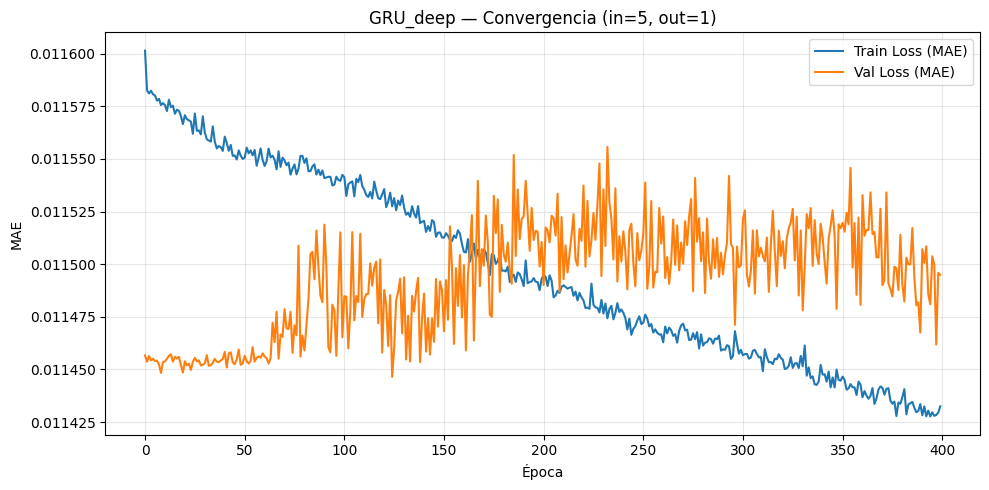

GRU_deep | in=5 out=1 | MAE train=0.011427 val=0.011495 test=0.012298 | params=101,655
Resultados guardados: GRU_deep | in=5 out=1 | MAE test=0.012298

[2/16] VENTANA: entrada=5, salida=5
Ventana entrada=5, salida=5
  X_train: (14571, 5, 23) | y_train: (14571, 23)
  X_test:  (1620, 5, 23)  | y_test:  (1620, 23)


/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Gráfica guardada: convergence_GRU_deep_in5_out5.png


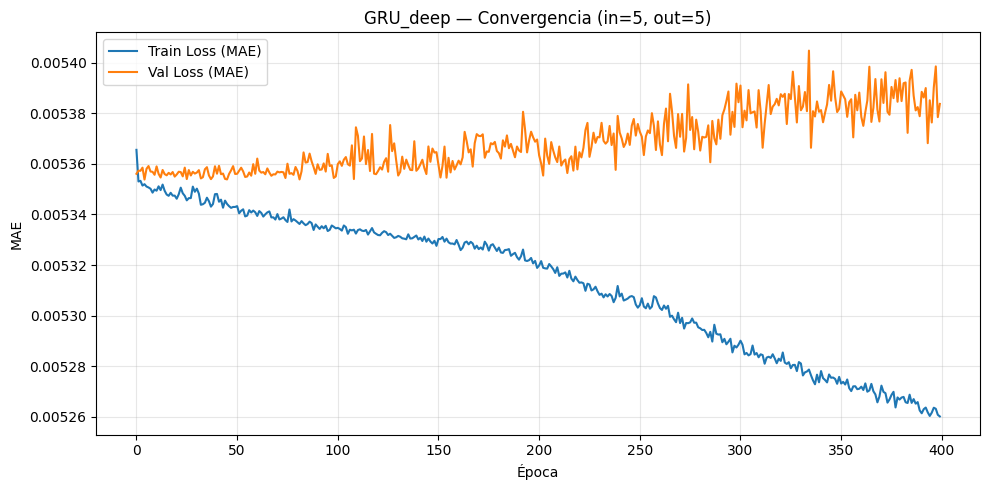

GRU_deep | in=5 out=5 | MAE train=0.005269 val=0.005384 test=0.005681 | params=101,655
Resultados guardados: GRU_deep | in=5 out=5 | MAE test=0.005681

[3/16] VENTANA: entrada=5, salida=30
Ventana entrada=5, salida=30
  X_train: (14549, 5, 23) | y_train: (14549, 23)
  X_test:  (1617, 5, 23)  | y_test:  (1617, 23)


/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Gráfica guardada: convergence_GRU_deep_in5_out30.png


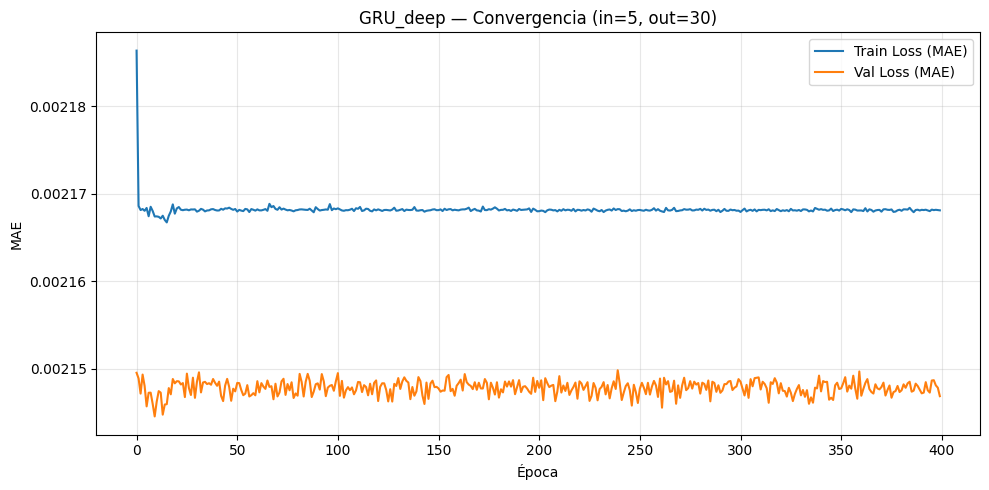

GRU_deep | in=5 out=30 | MAE train=0.002175 val=0.002147 test=0.002339 | params=101,655
Resultados guardados: GRU_deep | in=5 out=30 | MAE test=0.002339

[4/16] VENTANA: entrada=5, salida=90
Ventana entrada=5, salida=90
  X_train: (14495, 5, 23) | y_train: (14495, 23)
  X_test:  (1611, 5, 23)  | y_test:  (1611, 23)


/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Gráfica guardada: convergence_GRU_deep_in5_out90.png


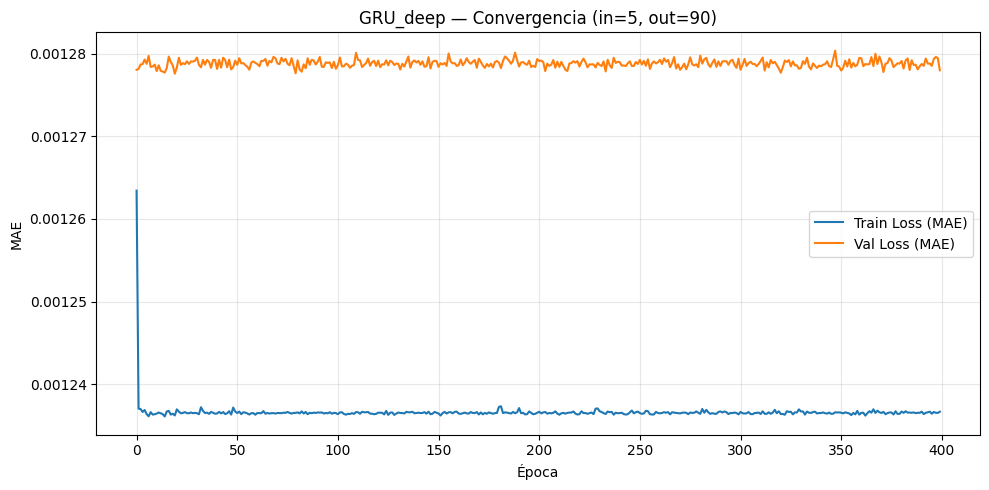

GRU_deep | in=5 out=90 | MAE train=0.001238 val=0.001278 test=0.001265 | params=101,655
Resultados guardados: GRU_deep | in=5 out=90 | MAE test=0.001265

[5/16] VENTANA: entrada=10, salida=1
Ventana entrada=10, salida=1
  X_train: (14571, 10, 23) | y_train: (14571, 23)
  X_test:  (1619, 10, 23)  | y_test:  (1619, 23)


/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Gráfica guardada: convergence_GRU_deep_in10_out1.png


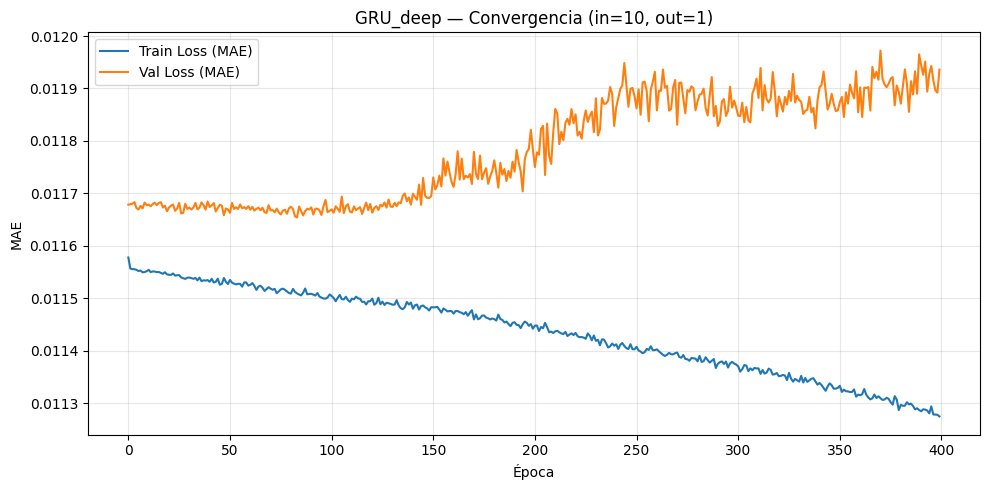

GRU_deep | in=10 out=1 | MAE train=0.011342 val=0.011936 test=0.012746 | params=101,655
Resultados guardados: GRU_deep | in=10 out=1 | MAE test=0.012746

[6/16] VENTANA: entrada=10, salida=5
Ventana entrada=10, salida=5
  X_train: (14567, 10, 23) | y_train: (14567, 23)
  X_test:  (1619, 10, 23)  | y_test:  (1619, 23)


/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Gráfica guardada: convergence_GRU_deep_in10_out5.png


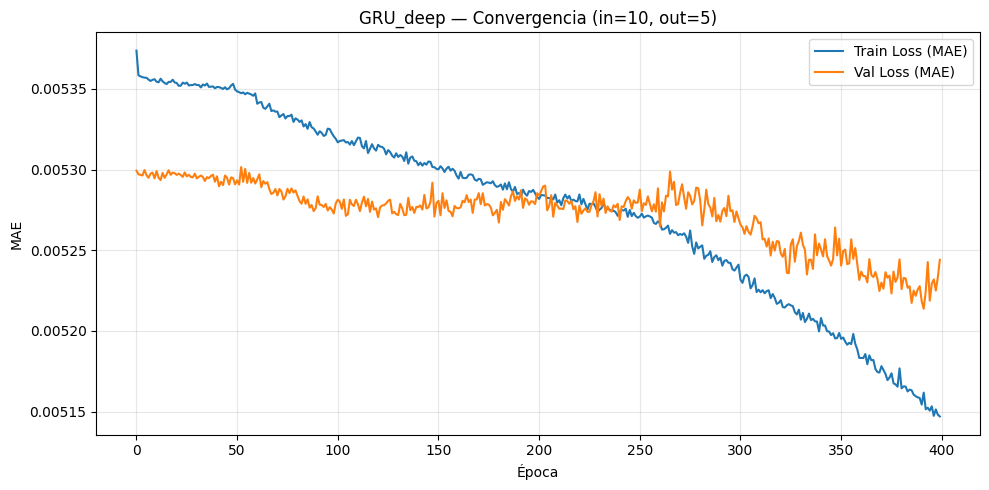

GRU_deep | in=10 out=5 | MAE train=0.005130 val=0.005244 test=0.005798 | params=101,655
Resultados guardados: GRU_deep | in=10 out=5 | MAE test=0.005798

[7/16] VENTANA: entrada=10, salida=30
Ventana entrada=10, salida=30
  X_train: (14544, 10, 23) | y_train: (14544, 23)
  X_test:  (1617, 10, 23)  | y_test:  (1617, 23)


/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Gráfica guardada: convergence_GRU_deep_in10_out30.png


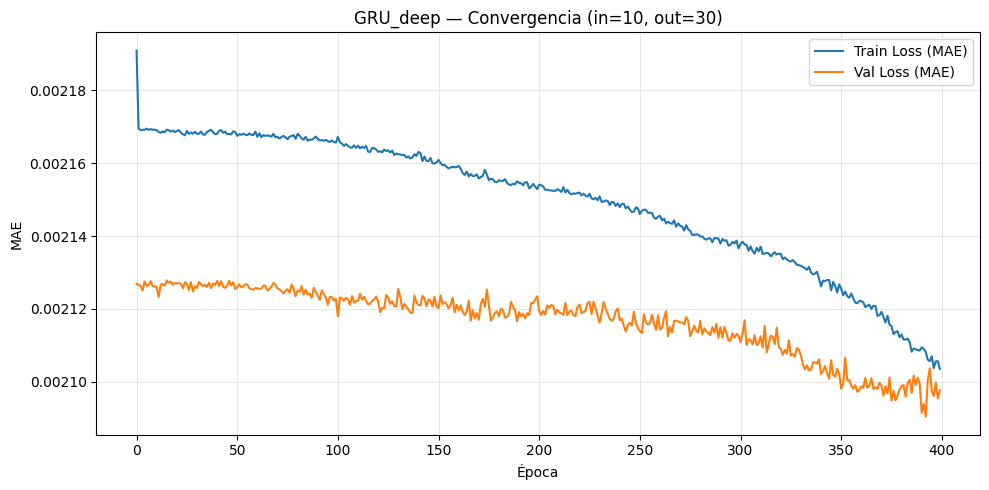

GRU_deep | in=10 out=30 | MAE train=0.002102 val=0.002098 test=0.002366 | params=101,655
Resultados guardados: GRU_deep | in=10 out=30 | MAE test=0.002366

[8/16] VENTANA: entrada=10, salida=90
Ventana entrada=10, salida=90
  X_train: (14490, 10, 23) | y_train: (14490, 23)
  X_test:  (1611, 10, 23)  | y_test:  (1611, 23)


/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Gráfica guardada: convergence_GRU_deep_in10_out90.png


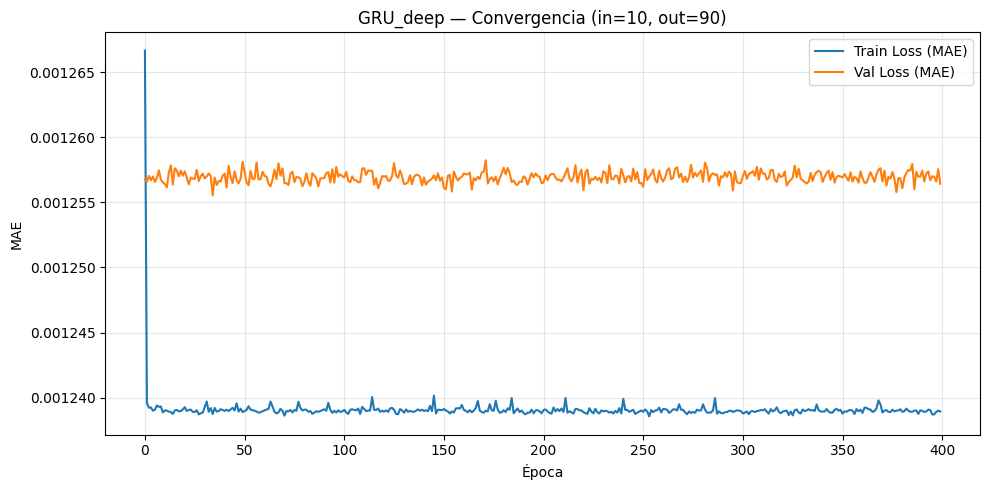

GRU_deep | in=10 out=90 | MAE train=0.001237 val=0.001256 test=0.001268 | params=101,655
Resultados guardados: GRU_deep | in=10 out=90 | MAE test=0.001268

[9/16] VENTANA: entrada=30, salida=1
Ventana entrada=30, salida=1
  X_train: (14553, 30, 23) | y_train: (14553, 23)
  X_test:  (1617, 30, 23)  | y_test:  (1617, 23)


/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Gráfica guardada: convergence_GRU_deep_in30_out1.png


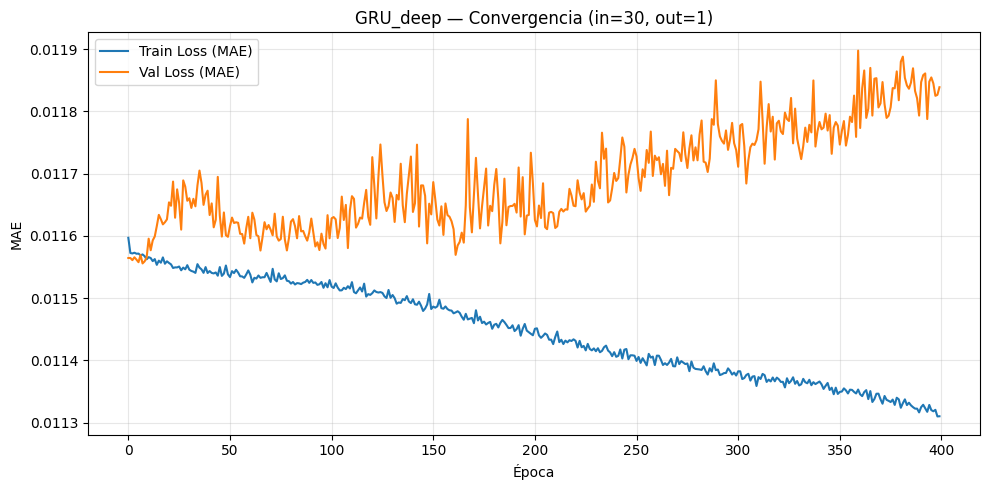

GRU_deep | in=30 out=1 | MAE train=0.011329 val=0.011839 test=0.012511 | params=101,655
Resultados guardados: GRU_deep | in=30 out=1 | MAE test=0.012511

[10/16] VENTANA: entrada=30, salida=5
Ventana entrada=30, salida=5
  X_train: (14549, 30, 23) | y_train: (14549, 23)
  X_test:  (1617, 30, 23)  | y_test:  (1617, 23)


/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Gráfica guardada: convergence_GRU_deep_in30_out5.png


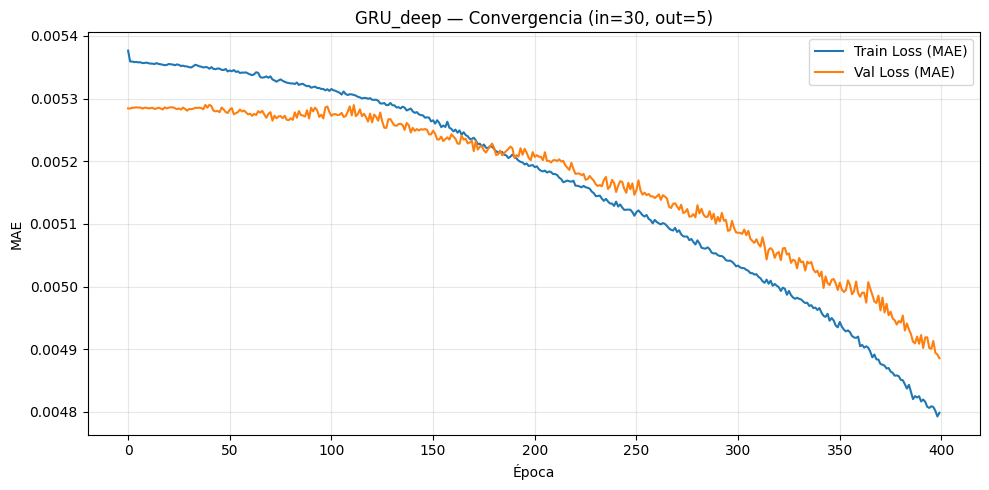

GRU_deep | in=30 out=5 | MAE train=0.004740 val=0.004886 test=0.006182 | params=101,655
Resultados guardados: GRU_deep | in=30 out=5 | MAE test=0.006182

[11/16] VENTANA: entrada=30, salida=30
Ventana entrada=30, salida=30
  X_train: (14526, 30, 23) | y_train: (14526, 23)
  X_test:  (1615, 30, 23)  | y_test:  (1615, 23)


/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Gráfica guardada: convergence_GRU_deep_in30_out30.png


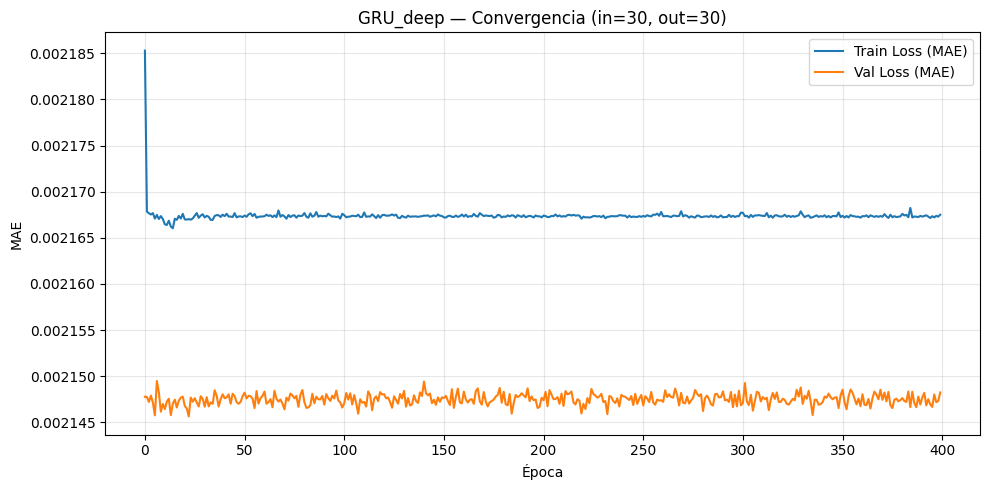

GRU_deep | in=30 out=30 | MAE train=0.002163 val=0.002148 test=0.002325 | params=101,655
Resultados guardados: GRU_deep | in=30 out=30 | MAE test=0.002325

[12/16] VENTANA: entrada=30, salida=90
Ventana entrada=30, salida=90
  X_train: (14472, 30, 23) | y_train: (14472, 23)
  X_test:  (1609, 30, 23)  | y_test:  (1609, 23)


/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Gráfica guardada: convergence_GRU_deep_in30_out90.png


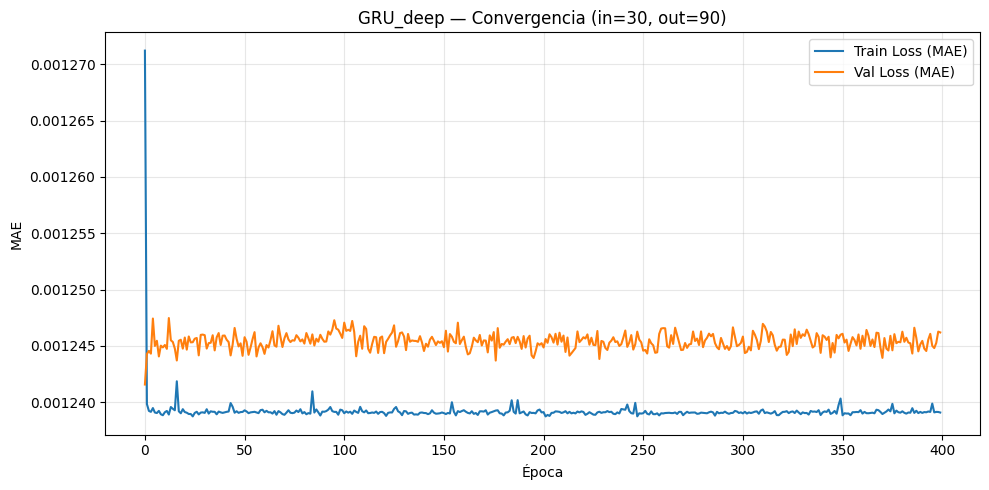

GRU_deep | in=30 out=90 | MAE train=0.001240 val=0.001246 test=0.001281 | params=101,655
Resultados guardados: GRU_deep | in=30 out=90 | MAE test=0.001281

[13/16] VENTANA: entrada=90, salida=1
Ventana entrada=90, salida=1
  X_train: (14499, 90, 23) | y_train: (14499, 23)
  X_test:  (1611, 90, 23)  | y_test:  (1611, 23)


/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Gráfica guardada: convergence_GRU_deep_in90_out1.png


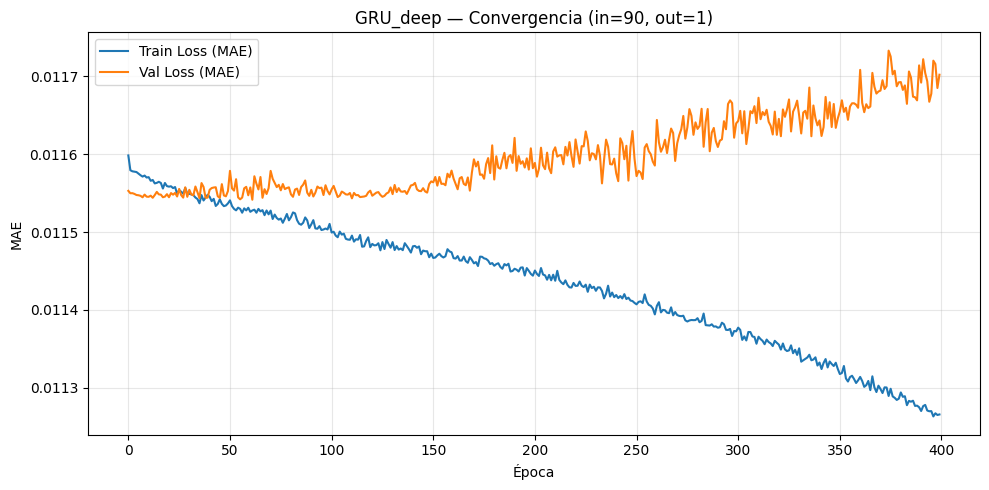

GRU_deep | in=90 out=1 | MAE train=0.011286 val=0.011702 test=0.012568 | params=101,655
Resultados guardados: GRU_deep | in=90 out=1 | MAE test=0.012568

[14/16] VENTANA: entrada=90, salida=5
Ventana entrada=90, salida=5
  X_train: (14495, 90, 23) | y_train: (14495, 23)
  X_test:  (1611, 90, 23)  | y_test:  (1611, 23)


/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Gráfica guardada: convergence_GRU_deep_in90_out5.png


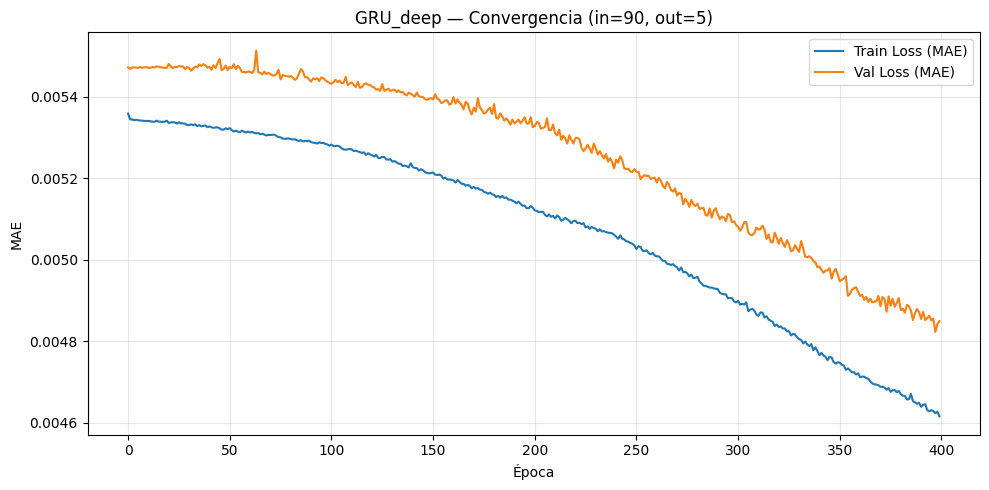

GRU_deep | in=90 out=5 | MAE train=0.004579 val=0.004849 test=0.006423 | params=101,655
Resultados guardados: GRU_deep | in=90 out=5 | MAE test=0.006423

[15/16] VENTANA: entrada=90, salida=30
Ventana entrada=90, salida=30
  X_train: (14472, 90, 23) | y_train: (14472, 23)
  X_test:  (1609, 90, 23)  | y_test:  (1609, 23)


/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Gráfica guardada: convergence_GRU_deep_in90_out30.png


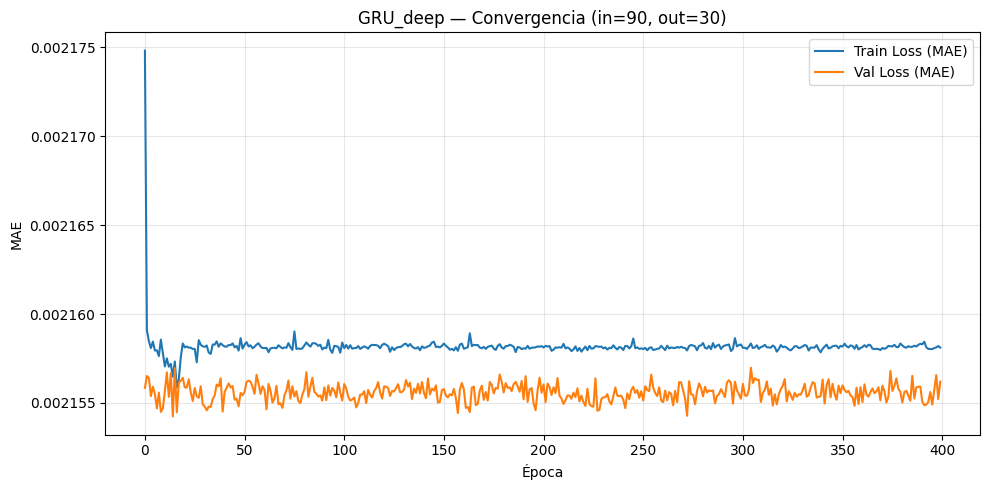

GRU_deep | in=90 out=30 | MAE train=0.002154 val=0.002156 test=0.002343 | params=101,655
Resultados guardados: GRU_deep | in=90 out=30 | MAE test=0.002343

[16/16] VENTANA: entrada=90, salida=90
Ventana entrada=90, salida=90
  X_train: (14418, 90, 23) | y_train: (14418, 23)
  X_test:  (1603, 90, 23)  | y_test:  (1603, 23)


/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Gráfica guardada: convergence_GRU_deep_in90_out90.png


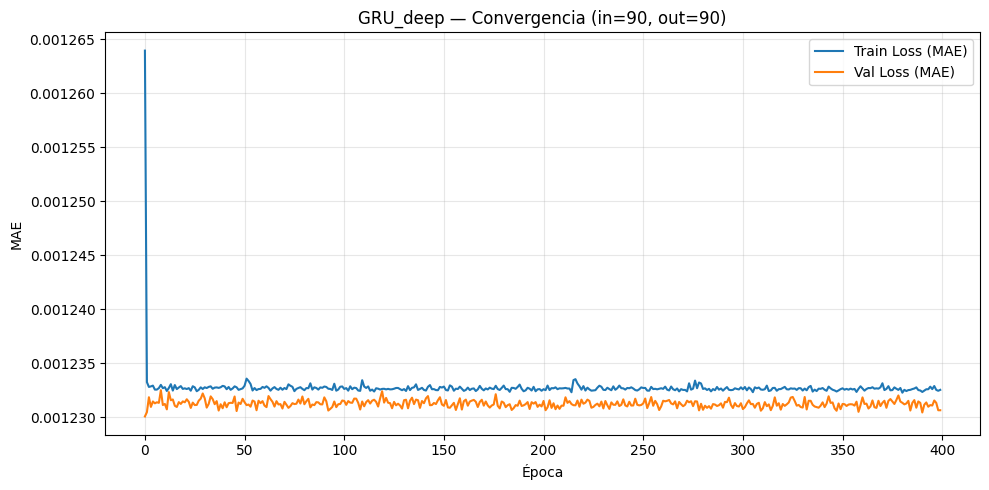

GRU_deep | in=90 out=90 | MAE train=0.001227 val=0.001231 test=0.001271 | params=101,655
Resultados guardados: GRU_deep | in=90 out=90 | MAE test=0.001271


ENTRENAMIENTO COMPLETADO: 16 modelos entrenados


In [38]:
all_results = []

MODEL_NAME = "GRU_deep"
total_models = len(INPUT_WINDOWS) * len(OUTPUT_WINDOWS)
current = 0

for iw in INPUT_WINDOWS:
    for ow in OUTPUT_WINDOWS:
        current += 1
        print(f"\n{'='*70}")
        print(f"[{current}/{total_models}] VENTANA: entrada={iw}, salida={ow}")
        print(f"{'='*70}")
        
        # Generar datos para esta combinación
        X_train_full, X_test, y_train_full, y_test = get_train_test(returns, iw, ow)
        
        # Resetear seeds para reproducibilidad
        tf.random.set_seed(42)
        np.random.seed(42)
        
        # Construir y entrenar
        model = build_gru(iw)
        result = train_and_evaluate(
            model, MODEL_NAME,
            X_train_full, X_test, y_train_full, y_test,
            iw, ow
        )
        all_results.append(result)
        
        # Liberar memoria
        del model
        tf.keras.backend.clear_session()

print(f"\n\n{'='*70}")
print(f"ENTRENAMIENTO COMPLETADO: {len(all_results)} modelos entrenados")
print(f"{'='*70}")

## 7. Tabla completa de resultados

In [39]:
results_df = pd.DataFrame(all_results)

print("RESULTADOS — GRU Deep")
print("=" * 85)
for _, row in results_df.iterrows():
    print(f"in={int(row['input_window']):>2}, out={int(row['output_window']):>2} | "
          f"MAE train={row['mae_train']:.6f} | val={row['mae_val']:.6f} | "
          f"test={row['mae_test']:.6f} | params={row['n_params']:,}")

RESULTADOS — GRU Deep
in= 5, out= 1 | MAE train=0.011427 | val=0.011495 | test=0.012298 | params=101,655
in= 5, out= 5 | MAE train=0.005269 | val=0.005384 | test=0.005681 | params=101,655
in= 5, out=30 | MAE train=0.002175 | val=0.002147 | test=0.002339 | params=101,655
in= 5, out=90 | MAE train=0.001238 | val=0.001278 | test=0.001265 | params=101,655
in=10, out= 1 | MAE train=0.011342 | val=0.011936 | test=0.012746 | params=101,655
in=10, out= 5 | MAE train=0.005130 | val=0.005244 | test=0.005798 | params=101,655
in=10, out=30 | MAE train=0.002102 | val=0.002098 | test=0.002366 | params=101,655
in=10, out=90 | MAE train=0.001237 | val=0.001256 | test=0.001268 | params=101,655
in=30, out= 1 | MAE train=0.011329 | val=0.011839 | test=0.012511 | params=101,655
in=30, out= 5 | MAE train=0.004740 | val=0.004886 | test=0.006182 | params=101,655
in=30, out=30 | MAE train=0.002163 | val=0.002148 | test=0.002325 | params=101,655
in=30, out=90 | MAE train=0.001240 | val=0.001246 | test=0.001281

## 8. Comparación con baselines

In [40]:
from src.evaluation import load_all_results

all_data = load_all_results()

baselines = all_data[all_data['model_type'] == 'baseline']
recurrents = all_data[all_data['model_type'] == 'recurrent']

print("COMPARACIÓN: GRU Deep vs Mejor Baseline por combinación")
print("=" * 85)
print(f"{'Ventana':<16} {'Mejor Baseline':<18} {'MAE Base':>10} {'MAE GRU':>10} {'Diferencia':>12} {'¿Bate?':>8}")
print("-" * 85)

for iw in INPUT_WINDOWS:
    for ow in OUTPUT_WINDOWS:
        mask_b = (baselines['input_window'] == iw) & (baselines['output_window'] == ow)
        best_b = baselines[mask_b].loc[baselines[mask_b]['mae_test'].idxmin()]
        
        mask_r = (recurrents['input_window'] == iw) & (recurrents['output_window'] == ow)
        sub_r = recurrents[mask_r]
        
        if len(sub_r) > 0:
            best_r = sub_r.loc[sub_r['mae_test'].idxmin()]
            diff = best_r['mae_test'] - best_b['mae_test']
            beats = "SI" if diff < 0 else "NO"
            print(f"in={iw:>2}, out={ow:>2}   {best_b['model_name']:<18} {best_b['mae_test']:>10.6f} "
                  f"{best_r['mae_test']:>10.6f} {diff:>+12.6f} {beats:>8}")

n_beats = 0
for iw in INPUT_WINDOWS:
    for ow in OUTPUT_WINDOWS:
        mask_b = (baselines['input_window'] == iw) & (baselines['output_window'] == ow)
        mask_r = (recurrents['input_window'] == iw) & (recurrents['output_window'] == ow)
        if len(recurrents[mask_r]) > 0:
            if recurrents[mask_r]['mae_test'].min() < baselines[mask_b]['mae_test'].min():
                n_beats += 1

print(f"\nResumen: los modelos recurrentes baten al baseline en {n_beats}/16 combinaciones.")

Cargado: recurrent_results.csv (16 resultados)
Cargado: baseline_results.csv (48 resultados)
Cargado: mixed_results.csv (16 resultados)
Total: 80 resultados combinados
COMPARACIÓN: GRU Deep vs Mejor Baseline por combinación
Ventana          Mejor Baseline       MAE Base    MAE GRU   Diferencia   ¿Bate?
-------------------------------------------------------------------------------------
in= 5, out= 1   Buy_and_Hold         0.012244   0.012298    +0.000054       NO
in= 5, out= 5   Buy_and_Hold         0.005583   0.005681    +0.000098       NO
in= 5, out=30   Buy_and_Hold         0.002320   0.002339    +0.000019       NO
in= 5, out=90   Buy_and_Hold         0.001267   0.001265    -0.000002       SI
in=10, out= 1   Buy_and_Hold         0.012244   0.012746    +0.000502       NO
in=10, out= 5   Buy_and_Hold         0.005584   0.005798    +0.000214       NO
in=10, out=30   Buy_and_Hold         0.002320   0.002366    +0.000046       NO
in=10, out=90   Buy_and_Hold         0.001267   0.001268 